In [1]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

In [8]:
"""JAWARA background profile (average over one area)"""
output_folder   = "../data/darwin_240718"
fpath = os.path.join("../data/jawara","jawara_patagonia_240718.nc")
ds_jawara = xr.open_dataset(fpath)

"""Reduce area"""
lats = slice(-52,-60)
# lats = slice(-44,-50)
lons = slice(278,284)
ds_jawara = ds_jawara.sel(latitude=lats, longitude=lons)

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
ds_jawara = ds_jawara.mean(dim=["latitude","longitude"])

"""Smooth the field using a Gaussian filter"""
sigma_gauss = 4  # higher -> more smoothing
# ds['var'].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=1)

ds_jawara

/tmp/ipykernel_391228/2751828345.py:14: RuntimeWarning: invalid value encountered in sqrt
  ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))


<xarray.Dataset> Size: 944kB
Dimensions:  (time: 48, level: 350)
Coordinates:
  * time     (time) datetime64[ns] 384B 2024-07-18 ... 2024-07-19T23:00:00
  * level    (level) int64 3kB 0 400 800 1200 ... 138400 138800 139200 139600
Data variables:
    u        (time, level) float64 134kB 8.58 10.95 12.24 ... 1.854 2.379 2.904
    v        (time, level) float64 134kB 0.2911 0.3806 1.381 ... -14.63 -14.96
    p        (time, level) float64 134kB 1.006e+05 9.571e+04 ... 0.0004341
    t        (time, level) float64 134kB 276.0 272.1 268.4 ... 576.4 580.2 584.1
    th       (time, level) float64 134kB 275.6 275.5 275.7 ... 1.482e+05 1.5e+05
    rho      (time, level) float64 134kB 1.274 1.23 ... 2.551e-09 2.479e-09
    N        (time, level) float64 134kB 0.002034 0.003025 ... 0.01745 0.0174

In [3]:
"""JAWARA background profile (select one point)"""
ds_jawara = xr.open_dataset(fpath)

"""Select point"""
lon = 360-73
lat = -55.5
ds_jawara = ds_jawara.sel(latitude=lat, longitude=lon, method="nearest")

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
# ds['var'].values = scipy.ndimage.gaussian_filter(ds[var].values, sigma, axes=1)
ds_jawara

/tmp/ipykernel_391228/919742177.py:11: RuntimeWarning: invalid value encountered in sqrt
  ds_jawara['N'] = (['time','level'], (g * np.gradient(logth, 400, axis=1))**(1/2))


<xarray.Dataset> Size: 944kB
Dimensions:    (time: 48, level: 350)
Coordinates:
  * time       (time) datetime64[ns] 384B 2024-07-18 ... 2024-07-19T23:00:00
  * level      (level) int64 3kB 0 400 800 1200 ... 138400 138800 139200 139600
    latitude   float32 4B -54.42
    longitude  float32 4B 286.9
Data variables:
    u          (time, level) float64 134kB ...
    v          (time, level) float64 134kB ...
    p          (time, level) float64 134kB 1.004e+05 9.556e+04 ... 0.0004302
    t          (time, level) float64 134kB ...
    th         (time, level) float64 134kB 277.5 277.2 ... 1.477e+05 1.496e+05
    rho        (time, level) float64 134kB 1.264 1.221 ... 2.544e-09 2.471e-09
    N          (time, level) float64 134kB nan 0.003153 ... 0.01755 0.0175

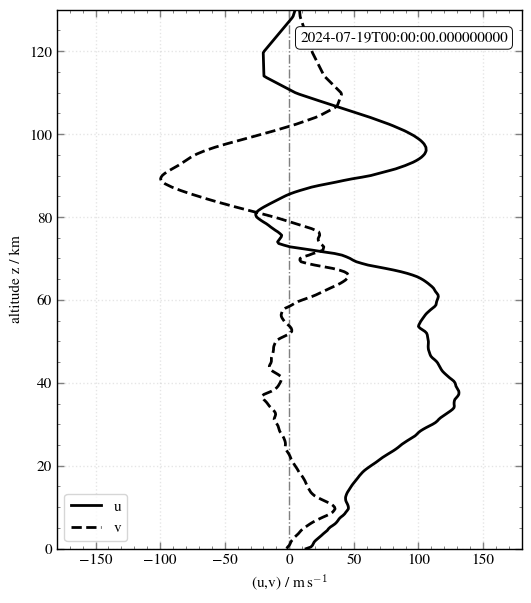

In [12]:
def plot_wind(t, ds, folder):
    fig, ax_wind = plt.subplots(1, 1, figsize=(6, 7))

    ut  = ds['u'].values
    vt  = ds['v'].values
    levels = ds['level'].values
    time = ds['time'][t].values

    """Wind profile plot"""
    lwl = 2
    ax_wind.axvline(0, ls="-.", lw=1, color='grey')

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-180, 180])
    ax_wind.set_ylim([0, 130])
    # ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=True, labeltop=False, color="grey")
    ax_wind.grid()

    ax_wind.text(0.97, 0.96, time, transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
         

    ax_wind.plot(ut[t,:], levels/1000, lw=lwl, ls='-',  color="black", label="u")
    ax_wind.plot(vt[t,:], levels/1000, lw=lwl, ls='--', color="black", label="v")
    ax_wind.legend(loc="lower left")

    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    fig_name = 'wind_' + '{:02d}'.format(t) + '.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')
folder   = "./data/jawara-env-240718"
plot_wind(24, ds_jawara, folder)

In [23]:
%%capture
for t in range(np.shape(ds['u'])[0]):
    plot_wind(t, ds_jawara, folder)
plt_helper.create_animation(folder,os.path.join(folder,"wind.mp4"),fps=4)

[rawvideo @ 0x5d04780] Stream #0: not enough frames to estimate rate; consider increasing probesize


ValueError: All images in a movie should have same size

In [7]:
"""Get JAWARA profiles for EULAG vertical grid"""
l = 321
ds = ds_jawara.isel(time=slice(18,30))
dsm = ds.mean(dim=["time"])

th = dsm['th'].values[0:l]
rho = dsm['rho'].values[0:l]
p = dsm['p'].values[0:l]
N  = (g/th * np.gradient(th, 400))**(1/2)
temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd))

u = ds_jawara['u'][25,0:l].values
v = ds_jawara['v'][25,0:l].values

levels = ds['level'][0:l].values
sigma = 5
lb =30
u[lb:] = scipy.ndimage.gaussian_filter(u[lb:], sigma, axes=0)   
v[lb:] = scipy.ndimage.gaussian_filter(v[lb:], sigma, axes=0)   
th = scipy.ndimage.gaussian_filter(th, sigma, axes=0)   
rho = scipy.ndimage.gaussian_filter(rho, sigma, axes=0)

sigma = 2
lb =30
u = scipy.ndimage.gaussian_filter(u, sigma, axes=0)   
v = scipy.ndimage.gaussian_filter(v, sigma, axes=0)   
print(f"umax: {u[0]}")

umax: 15.877800046422909


/tmp/ipykernel_4162547/1713050484.py:103: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.savefig(os.path.join(output_folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'
/home/b/b309199/venvs/post-venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/home/b/b309199/venvs/post-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


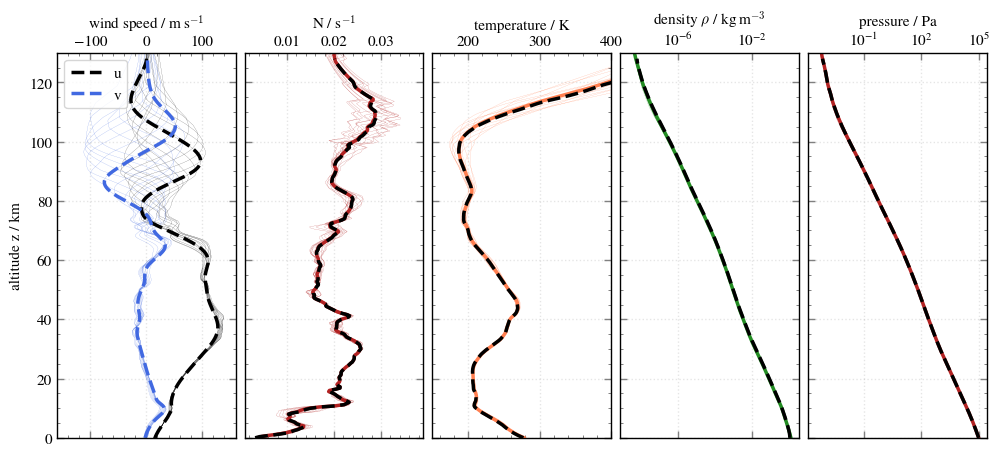

In [8]:
"""Vis env"""
# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
fig, axes = plt.subplots(1,5, figsize=(12,5),sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.05})
ax_wind  = axes[0]
ax_n     = axes[1]
ax_t     = axes[2]
ax_rho   = axes[3]
ax_p     = axes[4]

# ax.set_aspect("equal", adjustable='datalim')
"""Wind"""
lws = 0.1
lwl = 2.5
cu = "black"
cv = "royalblue"
for t in range(len(ds.time)):
    ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color=cu)
    ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color=cv)
# ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="u")
# ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="v")
ax_wind.plot(u, levels/1000, lw=lwl, ls='--', color=cu, label="u")
# ax_wind.plot(uphase1, levels/1000, lw=lwl, ls='dotted', color=cu)
ax_wind.plot(v, levels/1000, lw=lwl, ls='--', color=cv, label="v")
# ax_wind.plot(vphase1, levels/1000, lw=lwl, ls='dotted', color=cv)
ax_wind.legend(loc="upper left")

ax_wind.set_xlabel("wind speed / m$\,$s$^{-1}$")
ax_wind.set_ylabel("altitude z / km")
ax_wind.set_xlim([-160,160])
ax_wind.set_xticks([-100,0,100])
ax_wind.set_ylim([0,130])
ax_wind.xaxis.set_label_position('top')
ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_wind.grid()


"""N"""
for t in range(len(ds.time)):
    ax_n.plot(ds["N"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_n.plot(dsm["N"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_n.plot(N, levels/1000, lw=lwl, ls='--', color="black")
ax_n.set_xlabel("N / s$^{-1}$")
ax_n.set_xlim([0.001,0.039])

ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_minor_locator(AutoMinorLocator())
ax_n.yaxis.set_minor_locator(AutoMinorLocator())
ax_n.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_n.grid()

"""T"""
for t in range(len(ds.time)):
    ax_t.plot(ds["t"][t], ds["level"]/1000, lw=lws, color="coral")
ax_t.plot(dsm["t"], dsm["level"]/1000, lw=lwl, color="coral")
ax_t.plot(temp, levels/1000, lw=lwl, ls='--', color="black")

ax_t.set_xlabel("temperature / K")
ax_t.set_xlim(150,400)

ax_t.xaxis.set_label_position('top')
ax_t.xaxis.set_minor_locator(AutoMinorLocator())
ax_t.yaxis.set_minor_locator(AutoMinorLocator())
ax_t.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_t.grid()


"""Rho"""
for t in range(len(ds.time)):
    ax_rho.plot(ds["rho"][t], ds["level"]/1000, lw=lws, color="forestgreen")
ax_rho.plot(dsm["rho"], dsm["level"]/1000, lw=lwl, color="forestgreen")
ax_rho.plot(rho, levels/1000, lw=lwl, ls='--', color="black")
ax_rho.set_xlabel("density $\\rho$ / kg$\,$m$^{-3}$")
ax_rho.set_xscale('log')

ax_rho.xaxis.set_label_position('top')
ax_rho.xaxis.set_minor_locator(AutoMinorLocator())
ax_rho.yaxis.set_minor_locator(AutoMinorLocator())
ax_rho.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_rho.grid()

"""Pressure / Theta"""
for t in range(len(ds.time)):
    ax_p.plot(ds["p"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_p.plot(dsm["p"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_p.plot(p, levels/1000, lw=lwl, ls='--', color="black")
# ax_p.set_xlabel("$\Theta$ / K")
ax_p.set_xlabel("pressure / Pa")
# ax_p.set_xticks([2500,5000,7500])
ax_p.set_xscale('log')


ax_p.xaxis.set_label_position('top')
ax_p.xaxis.set_minor_locator(AutoMinorLocator())
ax_p.yaxis.set_minor_locator(AutoMinorLocator())
ax_p.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_p.grid()


"""Save figure"""
fig_name = "env_20240718.png"
fig.savefig(os.path.join(output_folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [10]:
"""Create NETCDF PMAP"""
# constants
Rd = 287.05       # J kg-1 K-1
cp = 1004.0       # J kg-1 K-1
p0 = 100000.0     # Pa
kappa = Rd / cp

ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)
ds['w'] = xr.zeros_like(ds['u'])
ds['exner'] = ((ds['rho'] * Rd * ds['th']) / p0) ** (kappa / (1.0 - kappa))
# ds['p'] = p0 * ds['exner'] ** (1.0 / kappa)
# ds['T'] = ds['th'] * ds['exner']

fname = "jawara_240719T01_400m_l321.nc"
# fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("../data/envs", fname))
ds

<xarray.Dataset> Size: 18kB
Dimensions:  (level: 321)
Coordinates:
  * level    (level) int64 3kB 0 400 800 1200 ... 126800 127200 127600 128000
Data variables:
    u        (level) float64 3kB 15.88 16.45 17.39 18.47 ... 0.1111 0.423 0.5815
    v        (level) float64 3kB -1.666 -1.351 -0.7948 ... 2.242 2.203 2.184
    th       (level) float64 3kB 280.2 280.4 280.8 ... 1.001e+05 1.003e+05
    rho      (level) float64 3kB 1.114 1.107 1.094 ... 5.89e-09 5.847e-09
    w        (level) float64 3kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    exner    (level) float64 3kB 0.9569 0.9549 0.951 ... 0.004888 0.004879

In [9]:
"""Create NETCDF"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "jawara_240719T01_pha0_l321.nc"
# fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

FileNotFoundError: [Errno 2] No such file or directory: '/work/bd0620/b309199/plteulag/src/data/envs/jawara_240719T01_pha0_l321.nc'

In [44]:
ds

<xarray.Dataset> Size: 13kB
Dimensions:  (level: 321)
Coordinates:
  * level    (level) int64 3kB 0 400 800 1200 ... 126800 127200 127600 128000
Data variables:
    u        (level) float64 3kB 13.67 14.68 16.22 17.73 ... 6.692 6.903 7.01
    v        (level) float64 3kB 3.813 4.479 5.502 6.536 ... 10.61 10.65 10.67
    th       (level) float64 3kB 280.7 280.8 281.2 ... 9.98e+04 1.001e+05
    rho      (level) float64 3kB 1.113 1.107 1.094 ... 5.916e-09 5.872e-09

In [66]:
# import shutil
# shutil.rmtree(folder)
folder = "../data/eulag/figures/saamer_JJA"
plt_helper.create_animation(folder,os.path.join(folder,"saamer_May.mp4"), fps=5)